In [45]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

## Carga y Preparación de Datos

In [46]:
# Cargar el objeto TabularPandas desde el pickle
from fastai.tabular.all import *

to = load_pickle('./df_train-tabular-object.pkl')

# Extraer features y target del conjunto de entrenamiento
X_train = to.train.xs.copy()
y_train = to.train.y.copy()

# Control del tamaño de la muestra de entrenamiento
np.random.seed(42)  # Para reproducibilidad
sample_frac = 1.0  # Usar 1.0 para usar todos los datos, o un valor menor para usar una fracción
print(f"\nTamaño original del conjunto de entrenamiento: {len(X_train)}")

if sample_frac < 1.0:
    sampled_indices = np.random.choice(len(X_train), size=int(len(X_train) * sample_frac), replace=False)
    X_train = X_train.iloc[sampled_indices]
    y_train = y_train.iloc[sampled_indices]
    print(f"Tamaño de la muestra ({sample_frac*100}%): {len(X_train)}")


# Los datos ya están procesados por FastAI, no necesitamos hacer más transformaciones
X_train_scaled = X_train
X_test = to.valid.xs.copy()
y_test = to.valid.y.values.ravel()
X_test_scaled = X_test

print("\nDimensiones finales del conjunto de datos:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

print("\nColumnas en el conjunto de datos:")
print(X_train_scaled.columns.tolist())


Tamaño original del conjunto de entrenamiento: 219636

Dimensiones finales del conjunto de datos:
X_train: (219636, 23)
X_test: (54908, 23)

Columnas en el conjunto de datos:
['start_date', 'end_date', 'created_on', 'pais', 'provincia', 'ciudad', 'barrio', 'title', 'description', 'property_type', 'rooms_na', 'bedrooms_na', 'bathrooms_na', 'surface_covered_na', 'covered_ratio_na', 'rooms', 'bedrooms', 'bathrooms', 'surface_covered', 'covered_ratio', 'year_created', 'month_created', 'age_of_ad']


## Entrenamiento del Modelo Bagging Regressor

In [47]:
# Crear el estimador base (DecisionTreeRegressor)
base_estimator = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

# Crear y entrenar el modelo Bagging Regressor
bagging_model = BaggingRegressor(
    estimator=base_estimator,  # Cambiado de base_estimator a estimator
    n_estimators=50,
    n_jobs=-1,
    random_state=42
)

# Entrenar el modelo
bagging_model.fit(X_train_scaled, y_train)

# Realizar predicciones
y_pred_train = bagging_model.predict(X_train_scaled)
y_pred_test = bagging_model.predict(X_test_scaled)

## Evaluación del Modelo

In [48]:
# Calcular métricas de rendimiento
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("Métricas de rendimiento:")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

Métricas de rendimiento:
Train RMSE: 642.5179
Test RMSE: 659.9889
Train R²: 0.7036
Test R²: 0.6893


### Feature importance

Análisis de Importancia de Features:


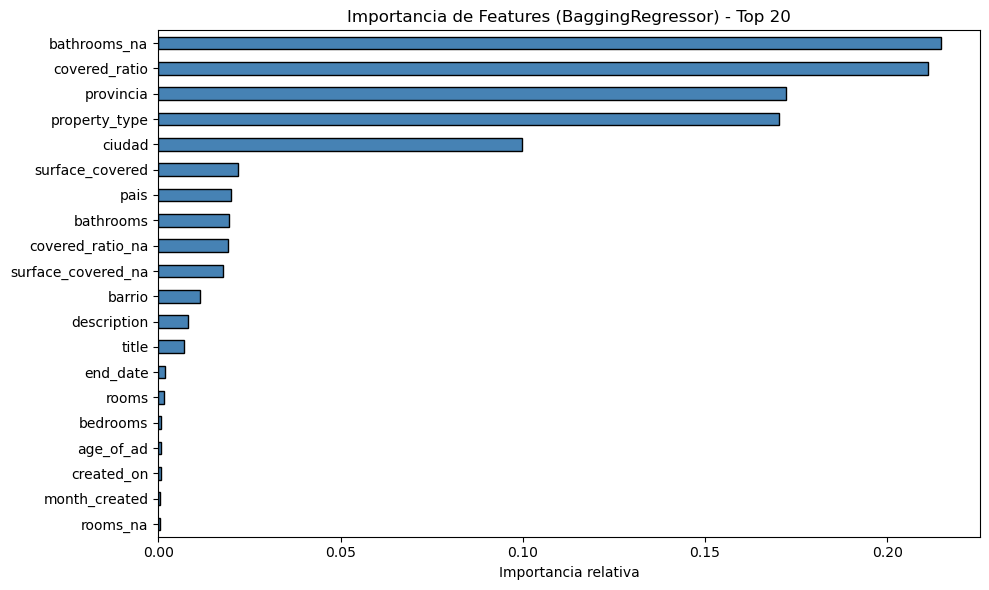


Top 10 features más importantes:
                    Importancia
bathrooms_na             0.2147
covered_ratio            0.2110
provincia                0.1721
property_type            0.1702
ciudad                   0.0997
surface_covered          0.0218
pais                     0.0200
bathrooms                0.0194
covered_ratio_na         0.0192
surface_covered_na       0.0176


In [49]:
def plot_feature_importance(model, X, top_k=20, model_name="BaggingRegressor"):
    # Calcular importancia promedio de características a través de todos los estimadores
    importances = np.mean([tree.feature_importances_ for tree in model.estimators_], axis=0)
    
    # Crear DataFrame con nombres de features e importancias
    imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
    top = imp.head(top_k)[::-1]  

    plt.figure(figsize=(10, max(6, top_k * 0.3)))
    top.plot(kind="barh", color="steelblue", edgecolor="black")
    plt.title(f"Importancia de Features ({model_name}) - Top {top_k}")
    plt.xlabel("Importancia relativa")
    plt.tight_layout()
    plt.show()

    return imp

# Calcular y mostrar importancia de features
print("Análisis de Importancia de Features:")
importances = plot_feature_importance(bagging_model, X_train_scaled)

# Mostrar los valores numéricos de importancia para las top 10 features
print("\nTop 10 features más importantes:")
print(importances.head(10).to_frame("Importancia").round(4))

## Búsqueda de hiperparámetros & model selection

In [50]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np
import random

def random_cv_bagging(X, y, param_distributions, n_iter=10, sample_size=0.3, n_splits=3, random_state=42):
    """
    Búsqueda aleatoria de hiperparámetros con validación cruzada y muestra reducida
    """
    # Tomar muestra aleatoria del conjunto de datos
    np.random.seed(random_state)
    sample_size = int(len(X) * sample_size)
    indices = np.random.choice(len(X), size=sample_size, replace=False)
    X_sample = X.iloc[indices]
    y_sample = y.iloc[indices]
    
    # Inicializar K-Fold y lista de resultados
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    results = []
    
    # Generar y evaluar combinaciones aleatorias de parámetros
    for i in range(n_iter):
        # Generar parámetros aleatorios
        params = {
            key: random.choice(value) if isinstance(value, list) else 
                 np.random.uniform(value[0], value[1]) if isinstance(value, tuple) else value
            for key, value in param_distributions.items()
        }
        
        # Redondear parámetros numéricos
        for param in ['n_estimators', 'max_depth', 'min_samples_leaf']:
            if param in params:
                params[param] = int(params[param])
        
        fold_scores = []
        
        # K-Fold Cross Validation
        for train_idx, val_idx in kf.split(X_sample):
            X_train, X_val = X_sample.iloc[train_idx], X_sample.iloc[val_idx]
            y_train, y_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]
            
            # Separar parámetros para el árbol base y el bagging
            tree_params = {
                'max_depth': params.get('max_depth', 10),
                'min_samples_leaf': params.get('min_samples_leaf', 1),
                'random_state': random_state
            }
            
            bagging_params = {k: v for k, v in params.items() 
                            if k not in ['max_depth', 'min_samples_leaf']}
            
            # Crear y entrenar modelo
            model = BaggingRegressor(
                estimator=DecisionTreeRegressor(**tree_params),
                **bagging_params,
                random_state=random_state,
                n_jobs=-1
            )
            
            # Entrenar y evaluar
            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            rmse = np.sqrt(mean_squared_error(y_val, y_pred))
            fold_scores.append(rmse)
        
        # Calcular métricas promedio
        mean_rmse = np.mean(fold_scores)
        std_rmse = np.std(fold_scores)
        
        # Guardar resultados
        results.append({
            'params': params,
            'mean_rmse': mean_rmse,
            'std_rmse': std_rmse,
            'fold_scores': fold_scores
        })
    
    # Ordenar resultados por RMSE medio
    results.sort(key=lambda x: x['mean_rmse'])
    return results

# Definir distribuciones de hiperparámetros
param_distributions = {
    'n_estimators': [50, 100, 200],
    'max_samples': (0.5, 1.0),  # Proporción de muestras para cada estimador
    'max_features': (0.5, 1.0),  # Proporción de features para cada estimador
    'max_depth': [5, 8, 10, 15],  # Para el DecisionTreeRegressor base
    'min_samples_leaf': [1, 3, 5, 10]  # Para el DecisionTreeRegressor base
}

In [57]:
# Ejecutar búsqueda aleatoria con validación cruzada
results = random_cv_bagging(
    X_train_scaled, y_train,
    param_distributions,
    n_iter=15,  # Número de combinaciones aleatorias
    sample_size=1,  
    n_splits=3,  # Número de folds
    random_state=42
)

# Obtener los mejores parámetros
best_params = results[0]['params'].copy()

# Separar parámetros para el árbol base y el bagging
tree_params = {
    'max_depth': best_params.get('max_depth', 10),
    'min_samples_leaf': best_params.get('min_samples_leaf', 1),
    'random_state': 42
}

bagging_params = {k: v for k, v in best_params.items() 
                 if k not in ['max_depth', 'min_samples_leaf']}

# Crear y entrenar el mejor modelo
best_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(**tree_params),
    **bagging_params,
    random_state=42,
    n_jobs=-1
)

# Entrenar y evaluar
best_model.fit(X_train_scaled, y_train)

# Asegurar que X_test_scaled tiene las mismas columnas que X_train_scaled y en el mismo orden
training_columns = X_train_scaled.columns
X_test_scaled_aligned = X_test_scaled[training_columns]

y_pred_train = best_model.predict(X_train_scaled)
y_pred_test = best_model.predict(X_test_scaled_aligned)

# Calcular métricas
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("\nMejores parámetros encontrados:")
for param, value in best_params.items():
    print(f"{param}: {value}")

print(f"\nMétricas del mejor modelo:")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {test_r2:.4f}")

# Actualizar el modelo principal
bagging_model = best_model


Mejores parámetros encontrados:
n_estimators: 100
max_samples: 0.7198787492178806
max_features: 0.7438896421460686
max_depth: 15
min_samples_leaf: 1

Métricas del mejor modelo:
Train RMSE: 477.2535
Test RMSE: 548.5965
Train R²: 0.8365
Test R²: 0.7854


## Visualización de Resultados

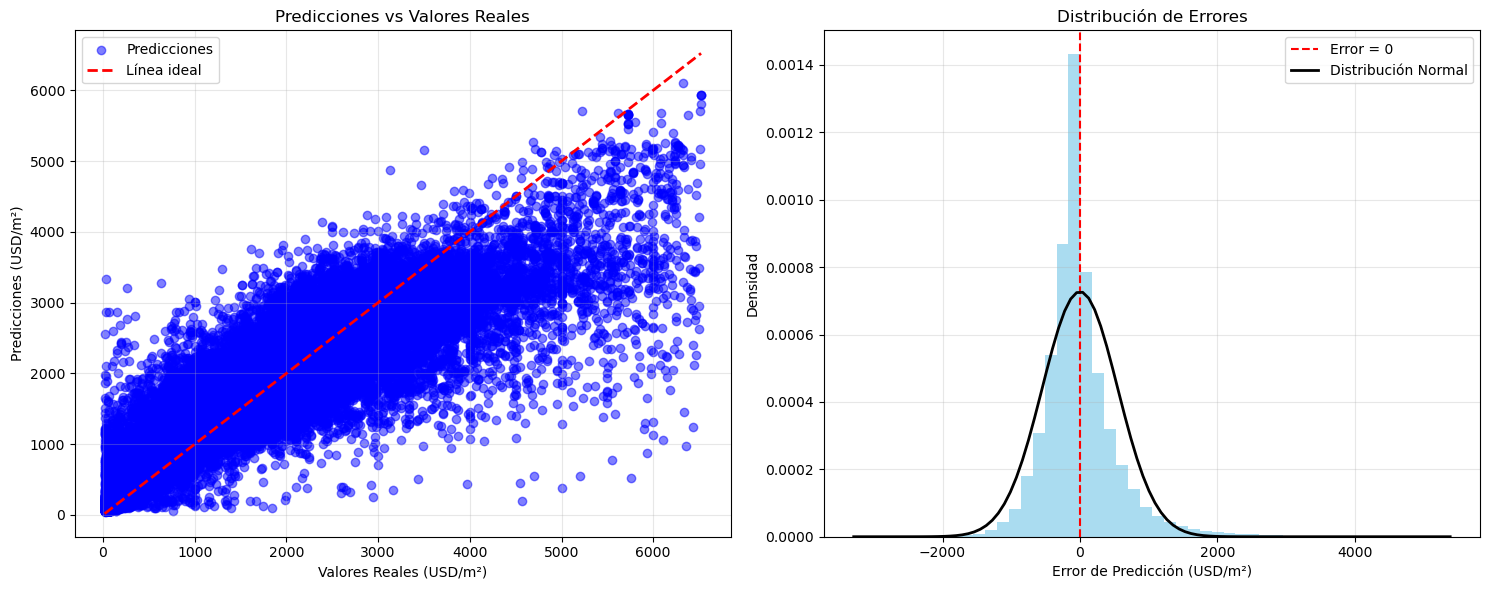


Estadísticas de los errores de predicción:
Error medio: -0.81 USD/m²
Error mediano: -62.17 USD/m²
Desviación estándar: 548.60 USD/m²
Error absoluto medio: 366.82 USD/m²


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Asegurar que X_test_scaled tiene las mismas columnas que X_train_scaled y en el mismo orden
training_columns = X_train_scaled.columns  # Usar las columnas del conjunto de entrenamiento
X_test_scaled_aligned = X_test_scaled[training_columns]

# 1. Predicciones vs Valores Reales y Distribución de Errores
y_pred_test = best_model.predict(X_test_scaled_aligned)
y_pred_train = best_model.predict(X_train_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Predicciones vs Valores Reales
ax1.scatter(y_test, y_pred_test, alpha=0.5, color='blue', label='Predicciones')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea ideal')
ax1.set_xlabel('Valores Reales (USD/m²)')
ax1.set_ylabel('Predicciones (USD/m²)')
ax1.set_title('Predicciones vs Valores Reales')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Distribución de Errores
errores = y_test - y_pred_test
ax2.hist(errores, bins=50, color='skyblue', alpha=0.7, density=True)
ax2.axvline(x=0, color='r', linestyle='--', label='Error = 0')

# Agregar curva de densidad normal
mu, sigma = stats.norm.fit(errores)
x = np.linspace(errores.min(), errores.max(), 100)
p = stats.norm.pdf(x, mu, sigma)
ax2.plot(x, p, 'k', linewidth=2, label='Distribución Normal')

ax2.set_xlabel('Error de Predicción (USD/m²)')
ax2.set_ylabel('Densidad')
ax2.set_title('Distribución de Errores')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Estadísticas de los errores
print("\nEstadísticas de los errores de predicción:")
print(f"Error medio: {np.mean(errores):.2f} USD/m²")
print(f"Error mediano: {np.median(errores):.2f} USD/m²")
print(f"Desviación estándar: {np.std(errores):.2f} USD/m²")
print(f"Error absoluto medio: {np.mean(np.abs(errores)):.2f} USD/m²")
